In [129]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings('ignore')

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

import pickle

In [7]:
fake = pd.read_csv("../Dataset/Fake.csv")
true = pd.read_csv("../Dataset/True.csv")

In [8]:
fake['label'] = 0
true['label'] = 1

In [9]:
fake.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [10]:
true.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [11]:
print(fake.shape)
print(true.shape)

(23481, 5)
(21417, 5)


In [12]:
print(fake.isnull().sum())
print(true.isnull().sum())

title      0
text       0
subject    0
date       0
label      0
dtype: int64
title      0
text       0
subject    0
date       0
label      0
dtype: int64


In [13]:
fake.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
 4   label    23481 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 917.4+ KB


In [14]:
true.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
 4   label    21417 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 836.7+ KB


In [15]:
print(fake.duplicated().sum())
print(true.duplicated().sum())

3
206


### Combining the Datasets

In [18]:
df = pd.concat([fake,true], ignore_index=True)

### Suffling the dataset

In [20]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [22]:
df = df.drop_duplicates()

In [23]:
df = df.drop(columns=['subject'])

## Visualization

### Class distribution

<function matplotlib.pyplot.show(close=None, block=None)>

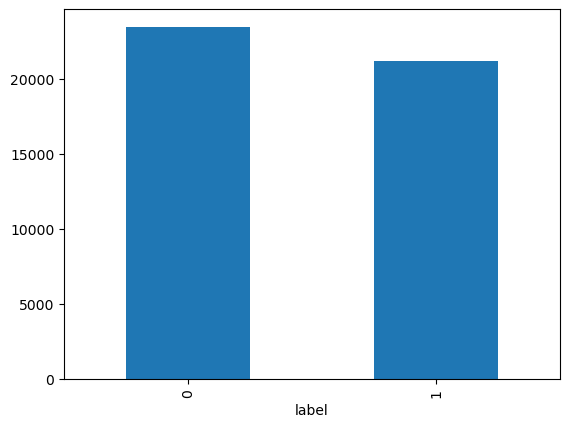

In [27]:
df['label'].value_counts().plot(kind='bar')
plt.show

### Text length analysis

In [30]:
df['text_length'] = df['text'].apply(len)

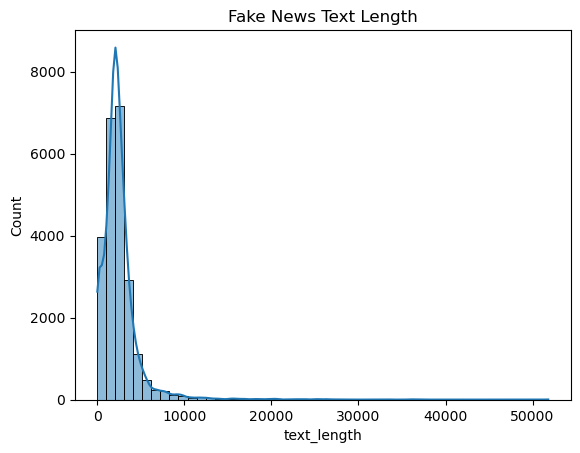

In [31]:
sns.histplot(df[df['label']==0]['text_length'], bins=50, kde=True)
plt.title("Fake News Text Length")
plt.show()

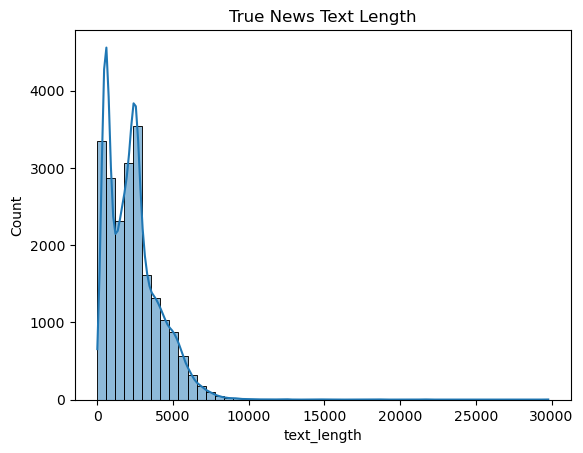

In [32]:
sns.histplot(df[df['label']==1]['text_length'], bins=50, kde=True)
plt.title("True News Text Length")
plt.show()

### Title length

In [35]:
df['title_length'] = df['title'].apply(len)

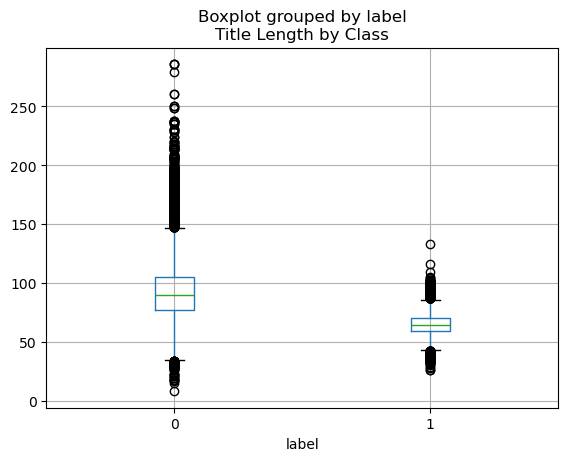

In [36]:
df.boxplot(column='title_length', by='label')
plt.title("Title Length by Class")
plt.show()

### Combining text

In [39]:
df['content'] = df['title'] + " " + df['text']

In [40]:
df = df.drop(columns=['title', 'text', 'date'])

In [41]:
df.head()

,label,text_length,title_length,content
0,0,1028,89,Ben Stein Calls Out 9th Circuit Court: Committ...
1,1,4820,55,Trump drops Steve Bannon from National Securit...
2,1,1848,64,Puerto Rico expects U.S. to lift Jones Act shi...
3,0,1244,89,OOPS: Trump Just Accidentally Confirmed He Le...
4,1,3137,55,Donald Trump heads for Scotland to reopen a go...


## Preprocessing

In [45]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [46]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english')) 

In [47]:
# Keep Negations 
stop_words = stop_words - {'no', 'not', 'never'}

In [48]:
# added bias word removal and improved preprocessing
bias_words = {'reuters'}
def preprocess(text):
    text = text.lower()
    
    # remove bias words
    for word in bias_words:
        text = text.replace(word, "")
    
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words)

df['content'] = df['content'].apply(preprocess)

### Train-Test Split

In [51]:
X = df['content']
y = df['label']

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## TF-IDF

In [54]:
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2), stop_words='english')

In [55]:
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

## Multinomial NB

In [58]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [59]:
y_pred = model.predict(X_test)

In [60]:
nb_acc = accuracy_score(y_test, y_pred)
nb_acc

0.9368986350413963

In [61]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      4652
           1       0.94      0.93      0.93      4286

    accuracy                           0.94      8938
   macro avg       0.94      0.94      0.94      8938
weighted avg       0.94      0.94      0.94      8938



## Logistic Regression

In [64]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [65]:
y_pred_lr = lr_model.predict(X_test)

In [66]:
lr_acc = accuracy_score(y_test, y_pred_lr)
lr_acc

0.9833296039382412

In [73]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      4652
           1       0.98      0.99      0.98      4286

    accuracy                           0.98      8938
   macro avg       0.98      0.98      0.98      8938
weighted avg       0.98      0.98      0.98      8938



## linear_SVC

In [78]:
linear_svc = LinearSVC(random_state=42)
linear_svc.fit(X_train, y_train)

LinearSVC(random_state=42)

In [79]:
pred_svc = linear_svc.predict(X_test)

In [81]:
svc_acc = accuracy_score(y_test, pred_svc)
svc_acc

0.9884761691653614

In [83]:
print(classification_report(y_test, pred_svc))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4652
           1       0.99      0.99      0.99      4286

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938



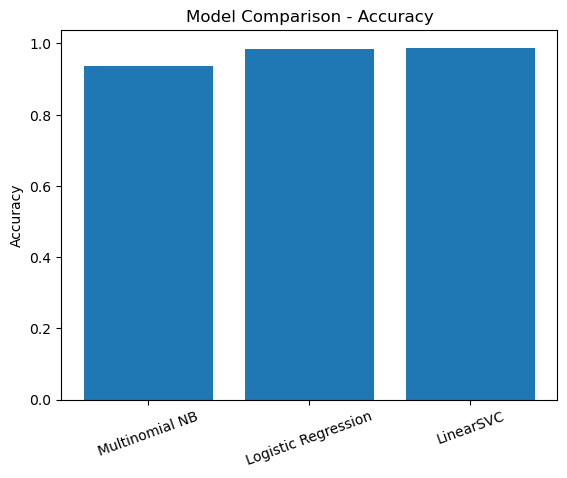

In [86]:
models = {"Multinomial NB": nb_acc, "Logistic Regression": lr_acc, "LinearSVC": svc_acc}
plt.bar(models.keys(), models.values())
plt.title("Model Comparison - Accuracy")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

### Pickle file 

In [133]:
pickle.dump(lr_model, open("fake_news_model.pkl", "wb"))

In [135]:
pickle.dump(vectorizer, open("tfidf_vectorizer.pkl", "wb"))